# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [29]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files
from src.evaluation.evaluator import filter_models
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.models.registry import TradModelLibrary

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

In [3]:
# Load WFV Performance files
loaded_dfs = load_csv_files(
    {
        'avg_perf': artifacts_paths['wfv_perf_dir'] / 'wfv_avg_perf_All.csv'
    }
)

avg_perf = loaded_dfs['avg_perf']
avg_perf.sort_values(by='sharpe', ascending=False, inplace=True)
print('Average Portfolio Performance Over All Steps:')
avg_perf.head(10)

Average Portfolio Performance Over All Steps:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
S&P500,0.054988,0.114250,0.163125,-0.089762,-0.033225,1.370600,0.024025
MeanVariancePortfolio,0.096537,0.109600,0.204425,-0.103987,-0.034875,1.398138,0.019687
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
BaseLSTM-custom_loss_6,0.059637,0.107438,0.165050,-0.095750,-0.031975,1.366150,0.022337
HierarchialRiskParity,0.045050,0.103025,0.157275,-0.088587,-0.027662,1.348688,0.019625
NaiveMVP,0.037525,0.078300,0.117900,-0.072063,-0.023050,1.257825,0.016362
GlobalMinimumVariance,0.037525,0.078300,0.117900,-0.072063,-0.023050,1.257825,0.016362
NestedClusteredOptimization,0.023500,0.059725,0.085875,-0.084587,-0.025412,1.221513,0.015025


## Univariate Analysis
### Overall View
#### Mean Sharpe comparison:

Models/Approaches that BEAT Equal Weight Mean Sharpe:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
S&P500,0.054988,0.114250,0.163125,-0.089762,-0.033225,1.370600,0.024025
MeanVariancePortfolio,0.096537,0.109600,0.204425,-0.103987,-0.034875,1.398138,0.019687
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
HierarchialRiskParity,0.045050,0.103025,0.157275,-0.088587,-0.027662,1.348688,0.019625
NaiveMVP,0.037525,0.078300,0.117900,-0.072063,-0.023050,1.257825,0.016362
GlobalMinimumVariance,0.037525,0.078300,0.117900,-0.072063,-0.023050,1.257825,0.016362
NestedClusteredOptimization,0.023500,0.059725,0.085875,-0.084587,-0.025412,1.221513,0.015025


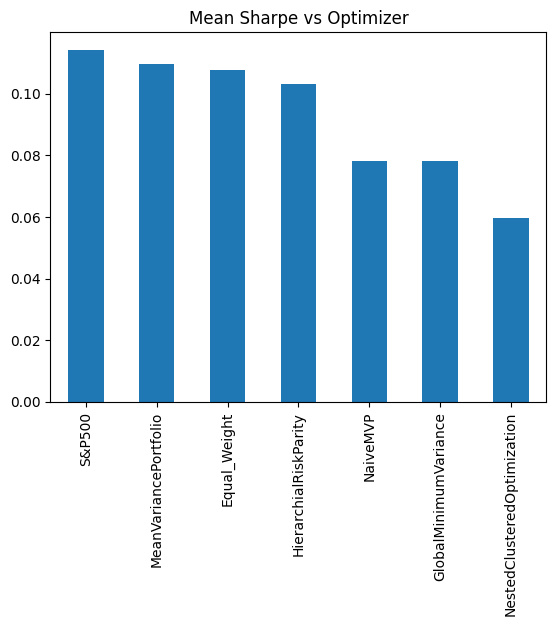

In [14]:
EQ_WT_NAME = 'Equal_Weight'
SP500_NAME = 'S&P500'

TradModelLibrary.autodiscover('src.models')
all_benches = TradModelLibrary.list_models()
all_benches.extend([EQ_WT_NAME, SP500_NAME])

# Filter models that beat Equal Weight Portfolio
filtered_perf, _ = filter_models(
    avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf['sharpe'].plot.bar(title='Mean Sharpe vs Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')
filtered_perf

In [9]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
1 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
BaseLSTM-custom_loss_6,0.059637,0.107438,0.16505,-0.09575,-0.031975,1.36615,0.022337


#### Metric Analysis:

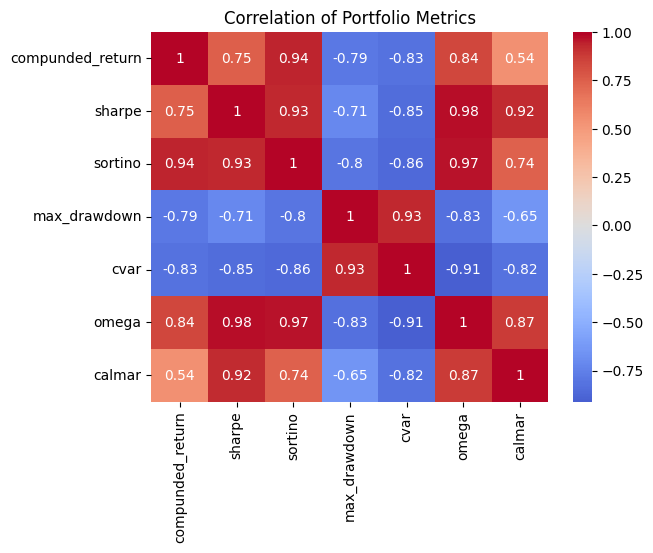

In [19]:
corr = avg_perf.corr()

# Plot heatmap
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Portfolio Metrics')
plt.show()

In [25]:
def high_corr_with_each_metric(corr, threshold=0.8):
    for metric in corr.columns:
        # Exclude self (corr=1.0)
        others = corr[metric][corr[metric].index != metric]
        high = others[abs(others) > threshold]
        if not high.empty:
            print(f"\n{metric} is highly correlated with:")
            for name, val in high.items():
                print(f"  {name}: {val:.3f}")

high_corr_with_each_metric(corr, threshold=0.85)


compunded_return is highly correlated with:
  sortino: 0.935

sharpe is highly correlated with:
  sortino: 0.926
  omega: 0.977
  calmar: 0.923

sortino is highly correlated with:
  compunded_return: 0.935
  sharpe: 0.926
  cvar: -0.865
  omega: 0.966

max_drawdown is highly correlated with:
  cvar: 0.931

cvar is highly correlated with:
  sortino: -0.865
  max_drawdown: 0.931
  omega: -0.910

omega is highly correlated with:
  sharpe: 0.977
  sortino: 0.966
  cvar: -0.910
  calmar: 0.875

calmar is highly correlated with:
  sharpe: 0.923
  omega: 0.875


Most metrics are highly correlated with each other, with sortino and omega showing high correlation with most of the other metrics.

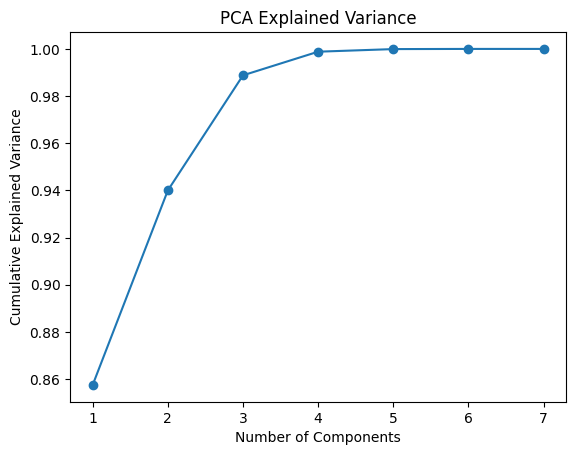

In [27]:
scaler = StandardScaler()
scaled_avg_perf = scaler.fit_transform(avg_perf)

pca = PCA()
pca.fit(scaled_avg_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 85% of the variance. At 5 princple components, almost 100% of the variance is explained.

In [30]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, avg_perf.columns, n_components=5, top_n=3)


Principal Component 1 (explained variance: 0.858)
  omega: 0.404
  sortino: 0.393
  cvar: -0.391

Principal Component 2 (explained variance: 0.082)
  calmar: 0.655
  compunded_return: -0.543
  sharpe: 0.345

Principal Component 3 (explained variance: 0.049)
  max_drawdown: 0.644
  cvar: 0.414
  sortino: 0.397

Principal Component 4 (explained variance: 0.010)
  cvar: 0.531
  max_drawdown: -0.456
  compunded_return: -0.447

Principal Component 5 (explained variance: 0.001)
  cvar: 0.596
  calmar: 0.534
  compunded_return: 0.394


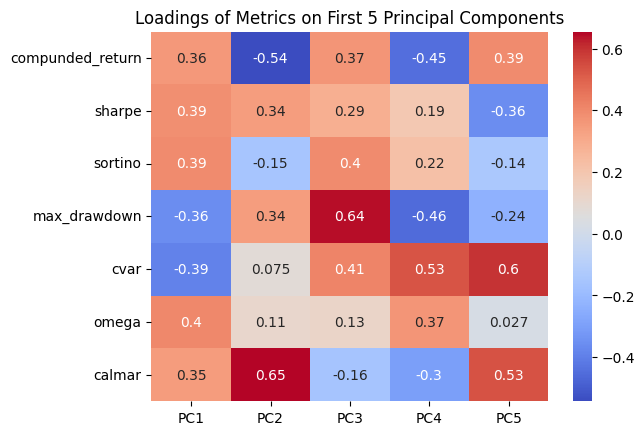

In [32]:
plt.figure()
sns.heatmap(loadings[:, :5], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(5)],
            yticklabels=avg_perf.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.show()